In [15]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import Lasso, ElasticNet, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split

from mrmr import mrmr_classif

import utils
from scripts.utils import run_classifiers_cv
from scripts.utils import run_classifiers_cv_clfs_rgs

# Dataset Collection

## Data filtering

- Remove rows if they answer the DASS-42 test less than 120 seconds
- Remove rows if they have VCL6, VCL9, or VCL12 equal to 1 (indicating they said that they know invented words)
- Remove rows if they have a variance of their answers to the 42 questions less than 0.05 (indicating they answered almost the same to all questions)
- Remove rows if they have age less than 17 (DASS-42 is a test for adult or old adolescent) or greater than 90 (indicating they probably made a mistake in their age)


## Data labelling
|                 | Depression (D) | Anxiety (A) | Stress (S) |
|-----------------|----------------|-------------|------------|
| Normal          |      0 - 9     |    0 - 7    |   0 - 14   |
| Mild            |     10 - 13    |    8 - 9    |   15 - 18  |
| Moderate        |     14 - 20    |   10 - 14   |   19 - 25  |
| Severate        |     21 - 27    |   15 - 19   |   26 - 33  |
| Extremly Severe |       28+      |     20+     |     34+    |

In [16]:
df = utils.clean_dataset_and_save()

Le dataset comporte 39775 lignes et 172 colonnes avant nettoyage et génération des labels.
Deleting (2494, 172) rows with testelapse less than 120 seconds
Deleting (263, 172) rows with VCL6, VCL9, or VCL12 equal to 1
Deleting (278, 173) rows with variance of their answers to the 42 questions less than 0.05
Deleting (0, 173) rows with age less than 17 or greater than 90
Deleting (0, 173) rows with gender less than 1 or greater than 3
Le dataset comporte 28772 lignes et 179 colonnes après nettoyage et génération des labels.
Saving cleaned dataset to C:\Users\thoma\PycharmProjects\projet-big-data\donnees_brut\dataset.csv


# Data Preprocessing

- Remove useless columns
- Transform categorical variables into numerical variables (one-hot encoding or target encoding)
- Divided the dataset into Train, Test, and Validation sets (80% Train, 10% Test, 10% Validation)
- Normalize the data

⚠️ It is important to normalize the data after splitting it into Train, Test, and Validation sets to avoid data leakage. The normalization parameters (mean and standard deviation) should be calculated only on the training set and then applied to the test and validation sets.
https://www.ibm.com/think/topics/data-leakage-machine-learning

In [17]:
df = utils.remove_useless_columns(df)
df = utils.encode_categorical_columns(df)

X, y, features_label = utils.split_features_target(df)

print(f"X shape: {X.shape}")
print(f"Y shape: {y.shape}")
print(f"{len(features_label)} features label: {features_label}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=1)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
X_val_scaled = scaler.fit_transform(X_val)

X shape: (28772, 85)
Y shape: (28772,)
85 features label: ['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A', 'Q7A', 'Q8A', 'Q9A', 'Q10A', 'Q11A', 'Q12A', 'Q13A', 'Q14A', 'Q15A', 'Q16A', 'Q17A', 'Q18A', 'Q19A', 'Q20A', 'Q21A', 'Q22A', 'Q23A', 'Q24A', 'Q25A', 'Q26A', 'Q27A', 'Q28A', 'Q29A', 'Q30A', 'Q31A', 'Q32A', 'Q33A', 'Q34A', 'Q35A', 'Q36A', 'Q37A', 'Q38A', 'Q39A', 'Q40A', 'Q41A', 'Q42A', 'age', 'voted', 'familysize', 'education_0', 'education_1', 'education_2', 'education_3', 'education_4', 'urban_0', 'urban_1', 'urban_2', 'urban_3', 'urban_4', 'gender_0', 'gender_1', 'gender_2', 'gender_3', 'gender_4', 'hand_0', 'hand_1', 'hand_2', 'hand_3', 'hand_4', 'religion_0', 'religion_1', 'religion_2', 'religion_3', 'religion_4', 'orientation_0', 'orientation_1', 'orientation_2', 'orientation_3', 'orientation_4', 'race_0', 'race_1', 'race_2', 'race_3', 'race_4', 'married_0', 'married_1', 'married_2', 'married_3', 'married_4']
X_train shape: (23017, 85), y_train shape: (23017,)
X_test shape: (2877, 8

# ACP

In [18]:
# utils.pca(X, Y, features_label, 0.85)

L'ACP ne permet pas de réduire suffisamment la dimensionnalité du jeu de données, nous allons simplement les normaliser et les utiliser pour entraîner les modèles de classification.

# Feature selection

## MRMR selection


In [28]:
dass_questions, labels = utils.get_data_for_mrmr(df)

selected_features, relevance, redundancy = mrmr_classif(dass_questions, labels, K=10, return_scores=True)

print("Selected features:", selected_features)

100%|██████████| 10/10 [00:00<00:00, 18.14it/s]

Selected features: ['Q21A', 'Q10A', 'Q13A', 'Q38A', 'Q34A', 'Q16A', 'Q17A', 'Q37A', 'Q26A', 'Q3A']


## ExtraTreesClassifier selection

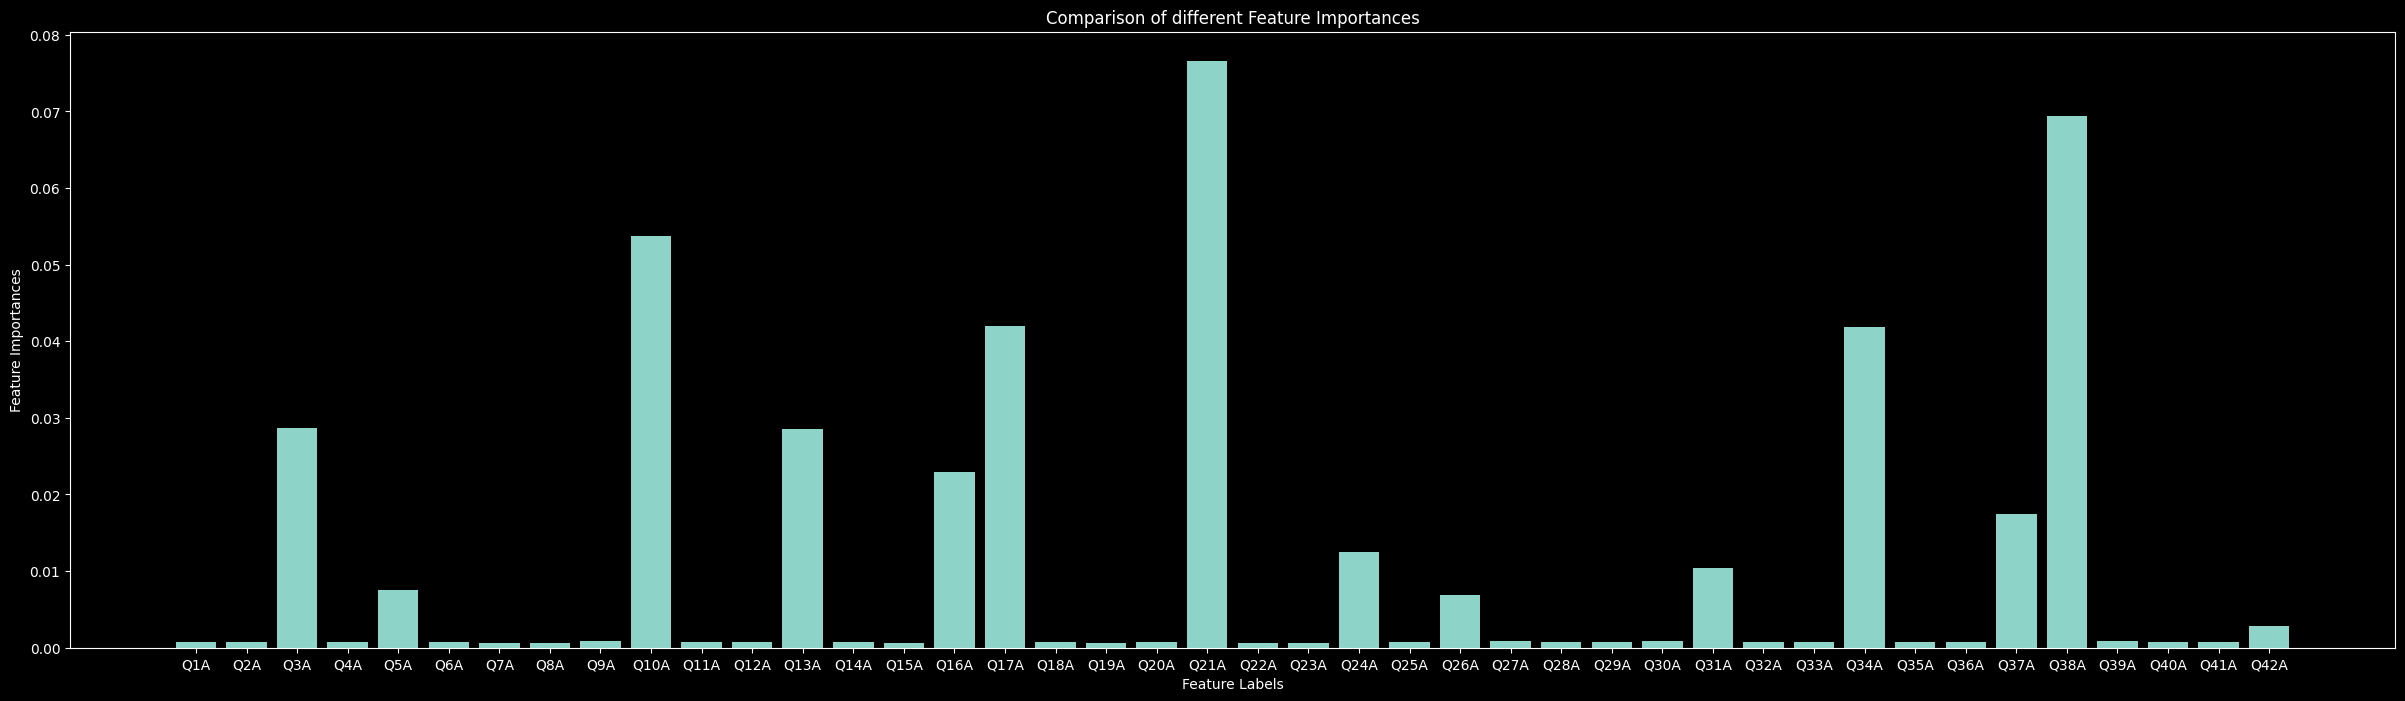

In [29]:
# Building the model
extra_tree_forest = ExtraTreesClassifier(n_estimators = 100, random_state = 1, criterion ='gini', max_features = None)

# Training the model
extra_tree_forest.fit(dass_questions.values, labels)

# Computing the importance of each feature
feature_importance = extra_tree_forest.feature_importances_

# Normalizing the individual importances
feature_importance_normalized = np.std([tree.feature_importances_ for tree in
                                        extra_tree_forest.estimators_],
                                        axis = 0)

plt.figure(figsize=(30, 8))
plt.bar(dass_questions.columns, feature_importance_normalized)
plt.xlabel('Feature Labels')
plt.ylabel('Feature Importances')
plt.title('Comparison of different Feature Importances')
plt.show()

In [21]:
from sklearn.decomposition import PCA
from scripts.utils import TARGET_COL

# print("############################################ Classification ############################################")

# clfs = {
#     # 'CART': DecisionTreeClassifier(random_state=1),
#     # 'ID3': DecisionTreeClassifier(criterion='entropy', random_state=1),  # entropy se rapproche le plus de ID3,
#     'MLP': MLPClassifier(hidden_layer_sizes=(10, 10), random_state=1),
#     'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
#     # 'BAGGING': BaggingClassifier(estimator=None, n_estimators=200, random_state=1, n_jobs=-1),
#     # 'ADA': AdaBoostClassifier(estimator=None, n_estimators=200, random_state=1),
#     'RF': RandomForestClassifier(
#         class_weight='balanced',
#         n_jobs=-1,
#         random_state=42
#     ),
#     # 'SVM': SVR()
# }
#
# run_classifiers_cv(clfs, X_scaled, Y)


print("############################################ Régression ############################################")

rgs = {
    'MLP': MLPRegressor(hidden_layer_sizes=(10, 10, 10), random_state=1),
    'KNN': KNeighborsRegressor(n_neighbors=3, n_jobs=-1),
    'LinearRegression': LinearRegression(),
    # 'SupportVectorRegression': SVR()
}

# Y_encoded = utils.target_encoding(df)

# run_classifiers_cv_clfs_rgs(rgs, X, df[TARGET_COL])
# utils.run_classifiers_cv_clfs_rgs_with_hold_out(rgs, X, df[TARGET_COL])

############################################ Régression ############################################


- Problème de régression
- Coder les variables par rapport à la target
- Sélection de variable
- utiliser shap pour expliquer (importance variable pour un individu) => matrice 3d chaque ligne un individu, une variable et une classe

temp data en attendant la validation

In [22]:
from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [100, 300, 500],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 5],
#     'max_features': ['sqrt', 'log2']
# }
#
# gs = GridSearchCV(
#     RandomForestClassifier(class_weight='balanced', random_state=42),
#     param_grid,
#     cv=5,
#     scoring='f1_macro',  # adapté aux 5 classes
#     n_jobs=-1
# )
#
# gs.fit(X_scaled, Y)
#
# print(gs.best_params_)

Pour améliorer nettement les résultats, priorité à ces points (*dans cet ordre*) :
1. **Supprimer la fuite de données (leakage)**Dans votre flux actuel, l’encodage et la normalisation sont faits avant la CV.Il faut tout mettre dans une Pipeline (encodage + scaling + modèle) et faire la CV dessus.
2. Utiliser une validation adaptée au multi-classe déséquilibréRemplacer KFold par StratifiedKFold.Optimiser f1_macro ou balanced_accuracy, pas seulement l’accuracy.
3. Faire le tuning d’hyperparamètres proprementRandomizedSearchCV (ou Optuna) avec scoring f1_macro, puis test final sur un split hold-out.Sans tuning, MLP, KNN et RF restent souvent sous-optimaux.
4. Gérer le déséquilibre des classesConserver class_weight='balanced' et ajouter, selon modèle, du sur-échantillonnage (SMOTE) dans une pipeline imblearn.
5. Revoir les variables d’entréeDans scripts/utils.py, remove_useless_columns enlève énormément de signal potentiel (notamment TIPI/VCL/Q\*).Si l’objectif est prédictif, tester plusieurs jeux de features (ablation) plutôt qu’un retrait massif.
6. Améliorer le prétraitement catégorielLe TargetEncoder est pertinent, mais il doit être appris uniquement dans chaque fold via pipeline (sinon fuite).Comparer aussi OneHotEncoder et CatBoost (souvent excellent sur tabulaire mixte).
7. Élargir les modèles tabulaires performantsTester XGBoost/LightGBM/CatBoost avec tuning (+ early stopping).Sur ce type de données, ils battent souvent KNN/MLP par défaut.
8. Vérifier la qualité du label cibleLa logique de generate_label peut créer une distribution artificielle des classes.Si le label est bruité, aucun modèle ne compensera : vérifier seuils cliniques et distribution finale.
En pratique, les gains les plus rapides viendront de (1) pipeline anti-leakage, (2) stratification + métrique f1_macro, (3) tuning sérieux.